# Week 1 — Dataset and Initial Data Preprocessing

Inventory the four CSV datasets, inspect schema and quality, and index optional Kaggle image folders. This phase does not train a model.


In [1]:
from pathlib import Path
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path.cwd()
if not (ROOT / 'heart_disease.csv').exists() and (ROOT.parent / 'heart_disease.csv').exists(): ROOT = ROOT.parent
CSV_FILES = sorted(ROOT.glob('*.csv'))
IMAGE_DIRS = [p for p in [ROOT/'data/images', ROOT/'images', ROOT/'Lung X-Ray Image', ROOT/'skin-disease-images'] if p.exists()]
print('Project root:', ROOT.resolve())
print('CSV files:', [p.name for p in CSV_FILES])
print('Image directories:', [str(p.relative_to(ROOT)) for p in IMAGE_DIRS] or 'none found (optional)')


Project root: /home/ubuntu/projecttest
CSV files: ['diabetes_dataset.csv', 'heart_disease.csv', 'infectious_disease.csv', 'lung_disease_data.csv']
Image directories: none found (optional)


In [2]:
datasets = {}
for path in CSV_FILES:
    try:
        df = pd.read_csv(path, on_bad_lines='warn')
    except TypeError:
        df = pd.read_csv(path, error_bad_lines=False)
    df.columns = [re.sub(r'\s+', ' ', str(c)).strip() for c in df.columns]
    datasets[path.stem] = df
    print(f'{path.name}: {len(df):,} rows x {len(df.columns)} columns')
rows = []
for name, df in datasets.items():
    rows.append({'dataset':name, 'rows':len(df), 'columns':len(df.columns), 'duplicates':int(df.duplicated().sum()), 'missing_cells':int(df.isna().sum().sum()), 'missing_%':round(df.isna().mean().mean()*100,2), 'numeric_columns':len(df.select_dtypes(include=np.number).columns), 'categorical_text_columns':len(df.select_dtypes(exclude=np.number).columns)})
profile_df = pd.DataFrame(rows).sort_values('rows', ascending=False)
display(profile_df)


diabetes_dataset.csv: 70,000 rows x 34 columns
heart_disease.csv: 10,000 rows x 21 columns
infectious_disease.csv: 11,571 rows x 13 columns
lung_disease_data.csv: 5,200 rows x 8 columns


/tmp/ipykernel_2181/2509480719.py:4: ParserWarning: Skipping line 7: expected 13 fields, saw 14
Skipping line 8: expected 13 fields, saw 14
Skipping line 37: expected 13 fields, saw 15
Skipping line 39: expected 13 fields, saw 14
Skipping line 54: expected 13 fields, saw 15
Skipping line 59: expected 13 fields, saw 15
Skipping line 65: expected 13 fields, saw 14
Skipping line 68: expected 13 fields, saw 15
Skipping line 71: expected 13 fields, saw 14
Skipping line 90: expected 13 fields, saw 14
Skipping line 102: expected 13 fields, saw 14
Skipping line 106: expected 13 fields, saw 15
Skipping line 127: expected 13 fields, saw 16
Skipping line 167: expected 13 fields, saw 14
Skipping line 178: expected 13 fields, saw 14
Skipping line 181: expected 13 fields, saw 14
Skipping line 189: expected 13 fields, saw 15
Skipping line 217: expected 13 fields, saw 14
Skipping line 295: expected 13 fields, saw 15
Skipping line 361: expected 13 fields, saw 14
Skipping line 367: expected 13 fields, s

,dataset,rows,columns,duplicates,missing_cells,missing_%,numeric_columns,categorical_text_columns
0,diabetes_dataset,70000,34,0,0,0.00,13,21
2,infectious_disease,11571,13,0,39215,26.07,0,13
1,heart_disease,10000,21,0,3054,1.45,9,12
3,lung_disease_data,5200,8,91,2400,5.77,3,5



### diabetes_dataset


,dtype,missing,missing_%,unique
Target,str,0,0.0,13
Genetic Markers,str,0,0.0,2
Autoantibodies,str,0,0.0,2
Family History,str,0,0.0,2
Environmental Factors,str,0,0.0,2
Insulin Levels,int64,0,0.0,45
Age,int64,0,0.0,80
BMI,int64,0,0.0,28
Physical Activity,str,0,0.0,3
Dietary Habits,str,0,0.0,2



### heart_disease


,dtype,missing,missing_%,unique
Alcohol Consumption,str,2586,25.86,4
Diabetes,str,30,0.30,3
Sugar Consumption,str,30,0.30,4
Cholesterol Level,float64,30,0.30,152
Age,float64,29,0.29,64
Triglyceride Level,float64,26,0.26,302
CRP Level,float64,26,0.26,9975
High LDL Cholesterol,str,26,0.26,3
High Blood Pressure,str,26,0.26,3
Low HDL Cholesterol,str,25,0.25,3



### infectious_disease


...


### lung_disease_data


,dtype,missing,missing_%,unique
Age,float64,300,5.77,71
Gender,str,300,5.77,3
Smoking Status,str,300,5.77,3
Lung Capacity,float64,300,5.77,502
Disease Type,str,300,5.77,6
Treatment Type,str,300,5.77,4
Hospital Visits,float64,300,5.77,15
Recovered,str,300,5.77,3


/tmp/ipykernel_2181/1154449235.py:9: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  if len(num.columns): num.iloc[:,:8].hist(ax=axes[i,1], bins=20)


/tmp/ipykernel_2181/1154449235.py:9: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  if len(num.columns): num.iloc[:,:8].hist(ax=axes[i,1], bins=20)


/tmp/ipykernel_2181/1154449235.py:9: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  if len(num.columns): num.iloc[:,:8].hist(ax=axes[i,1], bins=20)


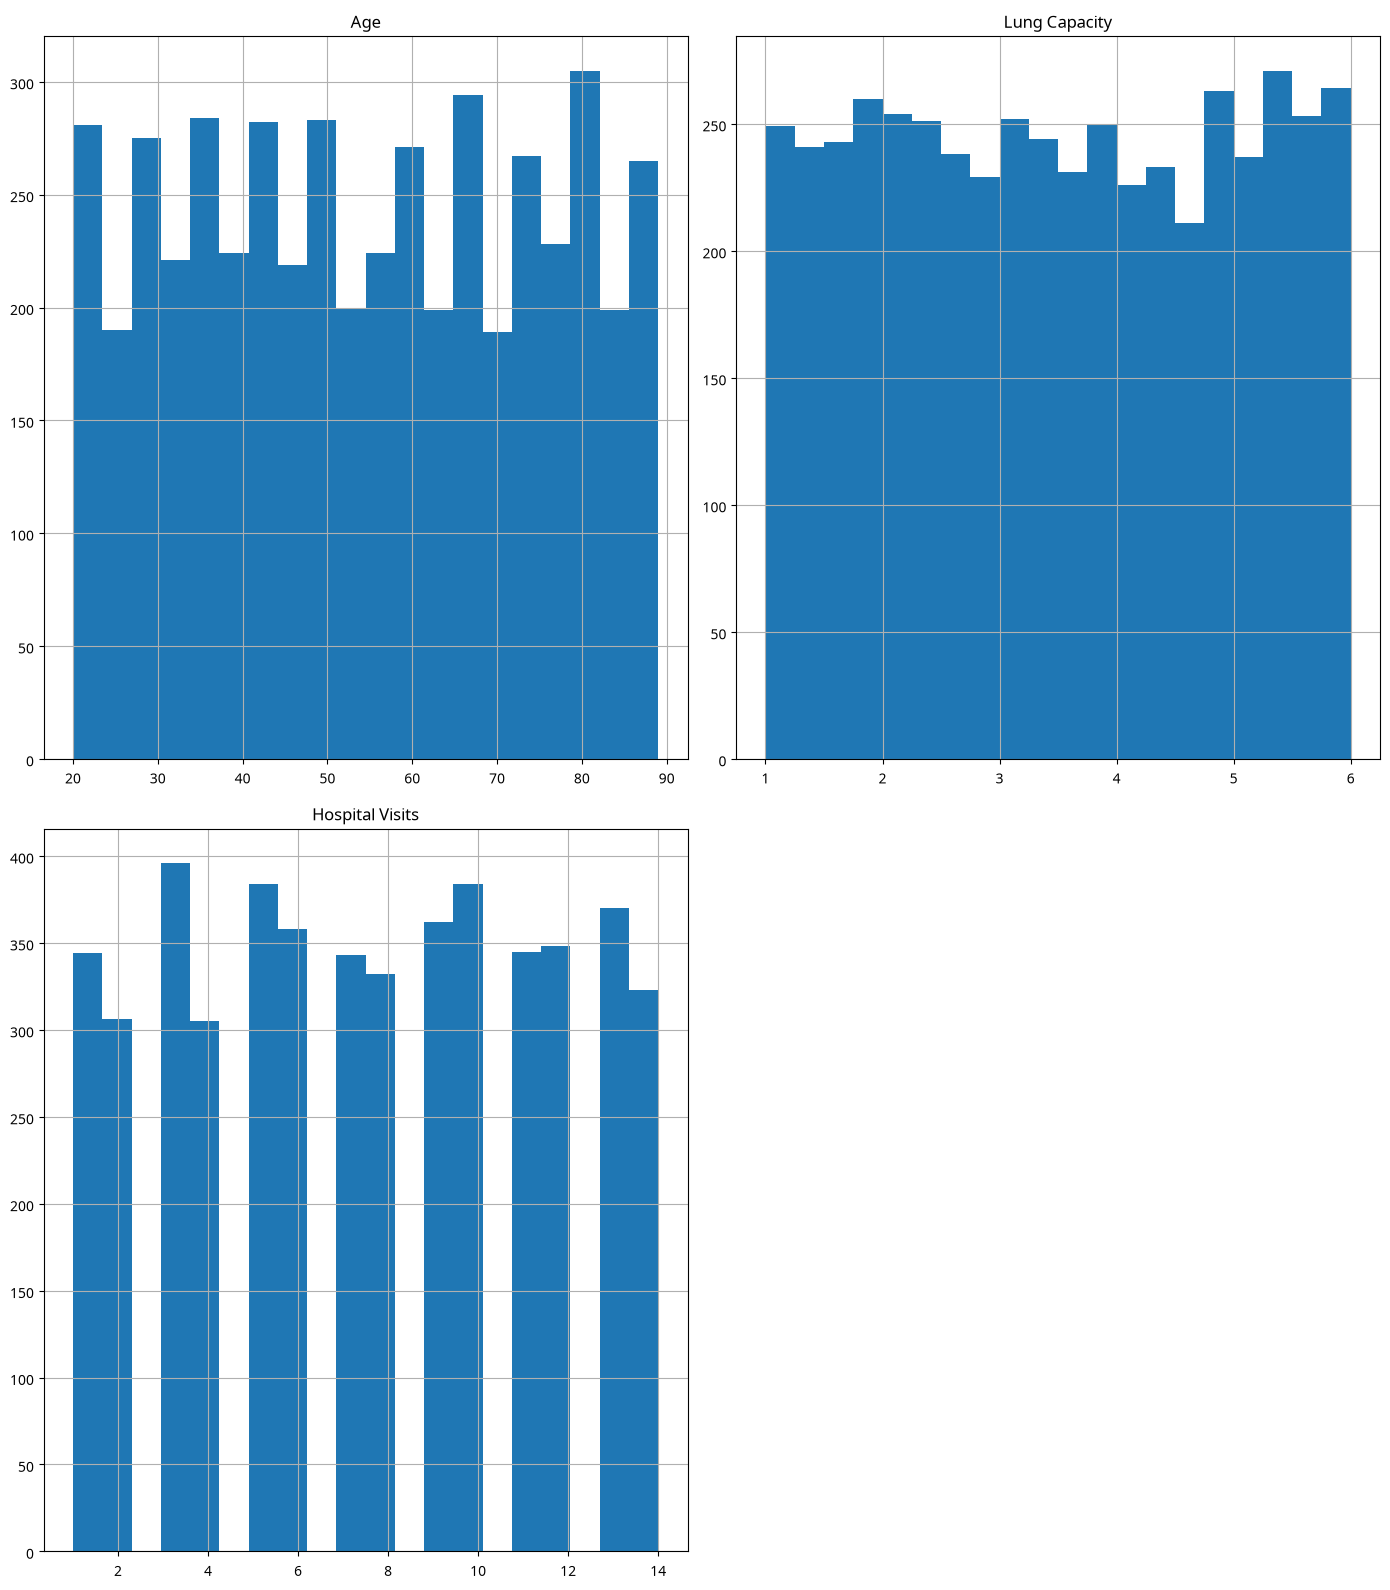

In [3]:
for name, df in datasets.items():
    print(f'\n### {name}')
    display(pd.DataFrame({'dtype':df.dtypes.astype(str), 'missing':df.isna().sum(), 'missing_%':(df.isna().mean()*100).round(2), 'unique':df.nunique(dropna=False)}).sort_values('missing_%', ascending=False).head(25))
fig, axes = plt.subplots(len(datasets), 2, figsize=(14, 4*len(datasets)))
if len(datasets) == 1: axes = np.array([axes])
for i, (name, df) in enumerate(datasets.items()):
    (df.isna().mean()*100).sort_values(ascending=False).head(12).plot.bar(ax=axes[i,0], title=f'{name}: missingness (%)')
    num = df.select_dtypes(include=np.number)
    if len(num.columns): num.iloc[:,:8].hist(ax=axes[i,1], bins=20)
    axes[i,1].set_title(f'{name}: numeric distributions')
plt.tight_layout()


In [4]:
exts = {'.jpg','.jpeg','.png','.bmp','.webp'}
records = [{'path':str(p), 'label':p.parent.name, 'bytes':p.stat().st_size} for folder in IMAGE_DIRS for p in folder.rglob('*') if p.suffix.lower() in exts]
image_df = pd.DataFrame(records)
print(f'Indexed {len(image_df):,} images')
if not image_df.empty: display(image_df.groupby('label').size().sort_values(ascending=False).to_frame('count'))
(ROOT/'artifacts').mkdir(exist_ok=True)
profile_df.to_csv(ROOT/'artifacts/week1_dataset_profile.csv', index=False)
if not image_df.empty: image_df.to_csv(ROOT/'artifacts/image_inventory.csv', index=False)


Indexed 0 images


## Exit criteria

Select one supervised target, document its meaning and class balance, decide how missing and duplicate rows will be handled, and verify image folder labels before Week 2. Do not concatenate unrelated disease datasets without a defined target.
